In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mujtabamatin/air-quality-and-pollution-assessment")

print("Path to dataset files:", path)

100%|██████████████████████████████████████| 84.1k/84.1k [00:00<00:00, 31.9MB/s]

Extracting files...
Path to dataset files: /Users/emmettralston/.cache/kagglehub/datasets/mujtabamatin/air-quality-and-pollution-assessment/versions/2


In [14]:
import pandas as pd

df = pd.read_csv(f"{path}/updated_pollution_dataset.csv")
print(df.head())


   Temperature  Humidity  PM2.5  PM10   NO2   SO2    CO  \
0         29.8      59.1    5.2  17.9  18.9   9.2  1.72   
1         28.3      75.6    2.3  12.2  30.8   9.7  1.64   
2         23.1      74.7   26.7  33.8  24.4  12.6  1.63   
3         27.1      39.1    6.1   6.3  13.5   5.3  1.15   
4         26.5      70.7    6.9  16.0  21.9   5.6  1.01   

   Proximity_to_Industrial_Areas  Population_Density Air Quality  
0                            6.3                 319    Moderate  
1                            6.0                 611    Moderate  
2                            5.2                 619    Moderate  
3                           11.1                 551        Good  
4                           12.7                 303        Good  


In [15]:
"""
Step 1 - Rename CSV columns to standardized feature names.

- Ensures consistent naming for the 9 required features.
- Prints before/after column headers so you can verify.

"""

rename_map = {
    "Temperature": "Temperature (°C)",
    "Humidity": "Humidity (%)",
    "PM2.5": "PM2.5 Concentration (µg/m³)",
    "PM10": "PM10 Concentration (µg/m³)",
    "NO2": "NO2 Concentration (ppb)",
    "SO2": "SO2 Concentration (ppb)",
    "CO": "CO Concentration (ppm)",
    "Proximity_to_Industrial_Areas": "Proximity to Industrial Areas (km)",
    "Population_Density": "Population Density (people/km²)",
}

print("Before renaming:\n", list(df.columns))

# Apply renaming where matches are found
df = df.rename(columns=rename_map)

print("\nAfter renaming:\n", list(df.columns))


Before renaming:
 ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality']

After renaming:
 ['Temperature (°C)', 'Humidity (%)', 'PM2.5 Concentration (µg/m³)', 'PM10 Concentration (µg/m³)', 'NO2 Concentration (ppb)', 'SO2 Concentration (ppb)', 'CO Concentration (ppm)', 'Proximity to Industrial Areas (km)', 'Population Density (people/km²)', 'Air Quality']


In [19]:
"""
Step 2 — Validate features & prepare labels for 4-class classification.

This cell:
1) Define required columns (exact names expected)
2) Basic column presence check
3) Normalize textual variants to the four standard category names
4) Drop rows with missing critical values (features or label).
5) Encode labels as integers 0..3 in a fixed order.
6) Print data readiness report 
"""

from typing import Dict, List, Tuple
import numpy as np
import pandas as pd

# ---- 1) Define required columns (exact names expected) ----
FEATURE_COLUMNS: List[str] = [
    "Temperature (°C)",
    "Humidity (%)",
    "PM2.5 Concentration (µg/m³)",
    "PM10 Concentration (µg/m³)",
    "NO2 Concentration (ppb)",
    "SO2 Concentration (ppb)",
    "CO Concentration (ppm)",
    "Proximity to Industrial Areas (km)",
    "Population Density (people/km²)",
]

# ---- 2) Basic column presence check ----
missing = [c for c in FEATURE_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(
        "Missing required feature columns. "
        f"Please add/rename these columns in your CSV: {missing}"
    )
# ---- 3) Normalize textual variants to the four standard category names ----
# (e.g., capitalization/whitespace variants).
label_col = "Air Quality"
df[label_col] = (
    df[label_col]
    .astype(str)
    .str.strip()
    .str.title()  
)

# ---- 4) Drop rows with missing critical values (features or label) ----
before_rows = len(df)
df = df.dropna(subset=FEATURE_COLUMNS + [label_col]).copy()
after_rows = len(df)

# ---- 5) Encode labels as integers 0..3 in a fixed order ----
CLASS_ORDER = ["Good", "Moderate", "Poor", "Hazardous"]
class_to_id: Dict[str, int] = {c: i for i, c in enumerate(CLASS_ORDER)}

# Validate that all labels fall into our 4 categories
unknown_labels = sorted(set(df[label_col]) - set(CLASS_ORDER))
if unknown_labels:
    raise ValueError(
        "Found labels outside the required 4 categories. "
        f"Unknown: {unknown_labels}. Please clean or map them."
    )

y = df[label_col].map(class_to_id).astype(int).to_numpy()

# Features matrix X (float32 for faster CPU math later)
X = df[FEATURE_COLUMNS].astype(np.float32).to_numpy()

# ---- 6) Print readiness report ----
def readiness_report() -> None:
    """Print a compact data readiness report for quick visual checks."""
    print("Data readiness summary")
    print("-" * 40)
    print(f"Rows before dropna: {before_rows}")
    print(f"Rows after  dropna: {after_rows}")
    print(f"Feature matrix X shape: {X.shape}  (rows, cols)")
    print(f"Target vector  y shape: {y.shape}")
    print("\nFeature preview (first 3 rows):")
    with pd.option_context("display.precision", 3):
        display(pd.DataFrame(X[:3], columns=FEATURE_COLUMNS))
    print("\nClass distribution:")
    counts = pd.Series(y).value_counts().sort_index()
    for idx, cnt in counts.items():
        print(f"  {idx} = {CLASS_ORDER[idx]:<10} : {cnt}")

readiness_report()


Data readiness summary
----------------------------------------
Rows before dropna: 5000
Rows after  dropna: 5000
Feature matrix X shape: (5000, 9)  (rows, cols)
Target vector  y shape: (5000,)

Feature preview (first 3 rows):


,Temperature (°C),Humidity (%),PM2.5 Concentration (µg/m³),PM10 Concentration (µg/m³),NO2 Concentration (ppb),SO2 Concentration (ppb),CO Concentration (ppm),Proximity to Industrial Areas (km),Population Density (people/km²)
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319.0
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611.0
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619.0



Class distribution:
  0 = Good       : 2000
  1 = Moderate   : 1500
  2 = Poor       : 1000
  3 = Hazardous  : 500


In [20]:
"""
Step 3 — Train/Validation/Test Split + Feature Standardization

This cell:
1. Splits X, y into train (70%), validation (15%), test (15%) sets.
2. Ensures stratified sampling so class ratios remain consistent.
3. Standardizes features with training mean/std only.
4. Produces NumPy arrays ready for neural network training.
"""

from sklearn.model_selection import train_test_split

# ---- 1) Initial train/test split (train 70%, temp_test 30%) ----
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,       # 30% held out for val+test
    stratify=y,           # keep class distribution consistent
    random_state=42
)

# ---- 2) Split temp into validation (15%) and test (15%) ----
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,       # half of 30% = 15%
    stratify=y_temp,
    random_state=42
)

# ---- 3) Standardize features (z-score) ----
# Compute mean/std on training data only
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)

# Avoid division by zero
train_std[train_std == 0] = 1.0

# Apply transform
X_train_std = (X_train - train_mean) / train_std
X_val_std   = (X_val   - train_mean) / train_std
X_test_std  = (X_test  - train_mean) / train_std

# ---- 4) Print split summary ----
print("Data split and standardized")
print("-" * 40)
print(f"Train set: {X_train_std.shape}, Labels: {y_train.shape}")
print(f"Val set:   {X_val_std.shape}, Labels: {y_val.shape}")
print(f"Test set:  {X_test_std.shape}, Labels: {y_test.shape}")
print("\nClass distribution (train/val/test):")
import numpy as np
for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = np.bincount(yy, minlength=4)
    print(f"{name:5}: " + " | ".join(f"{i}:{c}" for i, c in enumerate(counts)))


Data split and standardized
----------------------------------------
Train set: (3500, 9), Labels: (3500,)
Val set:   (750, 9), Labels: (750,)
Test set:  (750, 9), Labels: (750,)

Class distribution (train/val/test):
Train: 0:1400 | 1:1050 | 2:700 | 3:350
Val  : 0:300 | 1:225 | 2:150 | 3:75
Test : 0:300 | 1:225 | 2:150 | 3:75


In [21]:
"""
Step 4 — Define network architecture and implement forward pass.

Architecture:
- Input: 9 features
- Hidden1: 64 units, ReLU
- Hidden2: 32 units, ReLU
- Output: 4 units, Softmax (probabilities)

This cell:
1) Initializes weights & biases for each layer.
2) Implements ReLU and Softmax activation functions.
3) Implements forward pass to compute output probabilities.
"""

import numpy as np

# ---- 1) Set random seed for reproducibility ----
np.random.seed(42)

# ---- 2) Helper functions ----
def relu(z: np.ndarray) -> np.ndarray:
    """ReLU activation: max(0, z)."""
    return np.maximum(0, z)

def softmax(z: np.ndarray) -> np.ndarray:
    """
    Softmax activation for output layer.
    Converts raw logits into probabilities that sum to 1.
    """
    exp_shifted = np.exp(z - np.max(z, axis=1, keepdims=True))  # stability trick
    return exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)

# ---- 3) Weight initialization ----
def init_weights():
    """
    Initialize weights and biases for the network using He initialization for ReLU layers.
    Returns a dictionary of parameters.
    """
    params = {
        "W1": np.random.randn(9, 64) * np.sqrt(2. / 9),
        "b1": np.zeros((1, 64)),
        "W2": np.random.randn(64, 32) * np.sqrt(2. / 64),
        "b2": np.zeros((1, 32)),
        "W3": np.random.randn(32, 4) * np.sqrt(2. / 32),
        "b3": np.zeros((1, 4)),
    }
    return params

# ---- 4) Forward pass ----
def forward_pass(X: np.ndarray, params: dict) -> dict:
    """
    Perform forward propagation through the network.

    Args:
        X: Input features, shape (n_samples, 9)
        params: Dictionary of network parameters

    Returns:
        cache: Dictionary containing intermediate values for backprop
    """
    cache = {}
    cache["Z1"] = X @ params["W1"] + params["b1"]
    cache["A1"] = relu(cache["Z1"])
    cache["Z2"] = cache["A1"] @ params["W2"] + params["b2"]
    cache["A2"] = relu(cache["Z2"])
    cache["Z3"] = cache["A2"] @ params["W3"] + params["b3"]
    cache["A3"] = softmax(cache["Z3"])  # final output probabilities
    return cache

# ---- 5) Test forward pass on a small batch ----
params = init_weights()
sample_X = X_train_std[:5]  # take first 5 training examples
cache = forward_pass(sample_X, params)

print("Forward pass test — output probabilities (first 5 samples):")
print(cache["A3"])
print("Each row sums to:", np.sum(cache["A3"], axis=1))


Forward pass test — output probabilities (first 5 samples):
[[0.01571065 0.01353431 0.00173562 0.96901941]
 [0.23394784 0.19766453 0.02212457 0.54626306]
 [0.19189793 0.13597016 0.56320816 0.10892375]
 [0.03000454 0.00220667 0.18933856 0.77845022]
 [0.20063751 0.1059832  0.34627514 0.34710415]]
Each row sums to: [1. 1. 1. 1. 1.]


In [23]:
"""
Step 5 — Cross-Entropy Loss (with helpers)

This cell provides:
1) to_one_hot(y, num_classes): Convert integer labels to one-hot rows.
2) cross_entropy_loss(probs, y): Mean cross-entropy over a batch, numerically stable.
3) accuracy_from_probs(probs, y): Argmax-based classification accuracy.
4) A quick test on a small batch to validate the pipeline.

Requirements:
- Assumes `forward_pass` and `params` from Step 4 are available.
- Uses probabilities from softmax output: `cache["A3"]`.
"""

from typing import Tuple
import numpy as np

def to_one_hot(y: np.ndarray, num_classes: int) -> np.ndarray:
    """
    Convert a vector of integer labels into one-hot encoding.

    Args:
        y: shape (N,), integer labels in [0, num_classes-1]
        num_classes: number of classes (4 for this project)

    Returns:
        one_hot: shape (N, num_classes), with exactly one '1' per row.
    """
    N = y.shape[0]
    one_hot = np.zeros((N, num_classes), dtype=np.float32)
    one_hot[np.arange(N), y] = 1.0
    return one_hot

def cross_entropy_loss(probs: np.ndarray, y: np.ndarray, eps: float = 1e-12) -> float:
    """
    Compute mean categorical cross-entropy loss.

    Args:
        probs: Predicted probabilities from softmax, shape (N, C)
        y:     Integer labels, shape (N,), values in [0, C-1]
        eps:   Small epsilon for numerical stability (avoid log(0))

    Returns:
        Mean cross-entropy over the batch (scalar float).
    """
    # Clip to avoid log(0)
    probs_safe = np.clip(probs, eps, 1.0 - eps)
    # Select the probability of the true class for each sample
    N = y.shape[0]
    true_class_probs = probs_safe[np.arange(N), y]
    # Cross-entropy: -mean(log(p_true))
    loss = -np.mean(np.log(true_class_probs))
    return float(loss)

def accuracy_from_probs(probs: np.ndarray, y: np.ndarray) -> float:
    """
    Compute simple top-1 accuracy from predicted probabilities.

    Args:
        probs: Predicted probabilities, shape (N, C)
        y:     Integer labels, shape (N,)

    Returns:
        Accuracy in [0, 1].
    """
    preds = np.argmax(probs, axis=1)
    return float((preds == y).mean())

# ---- Quick sanity test on a small batch ----
# Use a small batch from the training set
batch_X = X_train_std[:32]
batch_y = y_train[:32]

# Forward pass with current (random) params
cache_test = forward_pass(batch_X, params)
probs_test = cache_test["A3"]

# Compute loss & accuracy
loss_test = cross_entropy_loss(probs_test, batch_y)
acc_test  = accuracy_from_probs(probs_test, batch_y)

print("Cross-entropy/accuracy sanity check on a small batch (random weights):")
print(f"Loss:     {loss_test:.4f}   (random nets typically ~ ln(C) ≈ {np.log(4):.4f})")
print(f"Accuracy: {acc_test:.2%}   (random nets typically ~ 25%)")


Cross-entropy/accuracy sanity check on a small batch (random weights):
Loss:     2.2947   (random nets typically ~ ln(C) ≈ 1.3863)
Accuracy: 15.62%   (random nets typically ~ 25%)


In [24]:
"""
Step 6 — Backpropagation for 2-layer MLP (ReLU, Softmax + Cross Entropy) + one SGD update.

This cell:
1) Implements backward_pass(...) to compute gradients for W1,b1,W2,b2,W3,b3.
2) Implements sgd_update(...) to apply an in-place parameter update.
3) Runs a short sanity check on a mini-batch to ensure loss trends downward.

Assumes from previous steps:
- forward_pass(X, params) -> cache with Z1,A1,Z2,A2,Z3,A3
- cross_entropy_loss(probs, y)
- to_one_hot(y, num_classes)
- X_train_std, y_train exist
- params (weights) exist
"""

from typing import Dict
import numpy as np

def relu_backward(dA: np.ndarray, Z: np.ndarray) -> np.ndarray:
    """
    Backward pass for ReLU.
    d/dZ ReLU(Z) = 1 where Z>0 else 0.
    """
    mask = (Z > 0).astype(dA.dtype)
    return dA * mask

def backward_pass(cache: Dict[str, np.ndarray],
                  params: Dict[str, np.ndarray],
                  X: np.ndarray,
                  y: np.ndarray,
                  num_classes: int = 4) -> Dict[str, np.ndarray]:
    """
    Compute gradients for a batch using vectorized backprop.

    Args:
        cache: dict with intermediates from forward_pass (Z1,A1,Z2,A2,Z3,A3)
        params: dict with weights/biases (W1,b1,W2,b2,W3,b3)
        X: input batch, shape (N, 9)
        y: integer labels, shape (N,)
        num_classes: number of output classes (4)

    Returns:
        grads: dict with dW1, db1, dW2, db2, dW3, db3
    """
    N = X.shape[0]
    A1, Z1 = cache["A1"], cache["Z1"]
    A2, Z2 = cache["A2"], cache["Z2"]
    A3, Z3 = cache["A3"], cache["Z3"]  # A3 is softmax probabilities

    # ---- Output layer gradient (Softmax + Cross-Entropy) ----
    # dZ3 = (A3 - Y_onehot) / N
    Y_onehot = to_one_hot(y, num_classes)
    dZ3 = (A3 - Y_onehot) / N

    # Gradients for W3, b3
    dW3 = A2.T @ dZ3                       # (32 x N) @ (N x 4) -> (32 x 4)
    db3 = np.sum(dZ3, axis=0, keepdims=True)  # (1 x 4)

    # ---- Hidden layer 2 backprop ----
    dA2 = dZ3 @ params["W3"].T             # (N x 4) @ (4 x 32) -> (N x 32)
    dZ2 = relu_backward(dA2, Z2)           # apply ReLU mask
    dW2 = A1.T @ dZ2                       # (64 x N) @ (N x 32) -> (64 x 32)
    db2 = np.sum(dZ2, axis=0, keepdims=True)  # (1 x 32)

    # ---- Hidden layer 1 backprop ----
    dA1 = dZ2 @ params["W2"].T             # (N x 32) @ (32 x 64) -> (N x 64)
    dZ1 = relu_backward(dA1, Z1)           # apply ReLU mask
    dW1 = X.T @ dZ1                        # (9 x N) @ (N x 64) -> (9 x 64)
    db1 = np.sum(dZ1, axis=0, keepdims=True)  # (1 x 64)

    grads = {"dW1": dW1, "db1": db1,
             "dW2": dW2, "db2": db2,
             "dW3": dW3, "db3": db3}
    return grads

def sgd_update(params: Dict[str, np.ndarray],
               grads: Dict[str, np.ndarray],
               lr: float = 0.05) -> None:
    """
    In-place SGD parameter update: theta <- theta - lr * grad.
    """
    for W_key, dW_key in [("W1", "dW1"), ("b1", "db1"),
                          ("W2", "dW2"), ("b2", "db2"),
                          ("W3", "dW3"), ("b3", "db3")]:
        params[W_key] -= lr * grads[dW_key]

# ---- Sanity check on a mini-batch ----
batch_size = 64
batch_X = X_train_std[:batch_size]
batch_y = y_train[:batch_size]

# Forward -> loss/acc BEFORE update
cache_before = forward_pass(batch_X, params)
probs_before = cache_before["A3"]
loss_before = cross_entropy_loss(probs_before, batch_y)
acc_before  = accuracy_from_probs(probs_before, batch_y)

# Backward -> gradients
grads = backward_pass(cache_before, params, batch_X, batch_y)

# One SGD step
sgd_update(params, grads, lr=0.05)

# Forward -> loss/acc AFTER update
cache_after = forward_pass(batch_X, params)
probs_after = cache_after["A3"]
loss_after = cross_entropy_loss(probs_after, batch_y)
acc_after  = accuracy_from_probs(probs_after, batch_y)

print("One-step SGD sanity check (mini-batch of 64)")
print(f"Loss  before: {loss_before:.4f} | after: {loss_after:.4f}  (should go ↓ slightly)")
print(f"Acc   before: {acc_before:.2%} | after: {acc_after:.2%}   (may or may not go ↑ immediately)")


One-step SGD sanity check (mini-batch of 64)
Loss  before: 2.3250 | after: 1.7574  (should go ↓ slightly)
Acc   before: 12.50% | after: 26.56%   (may or may not go ↑ immediately)


In [32]:
"""
Step 7 — Full training loop with mini-batch SGD, validation tracking, and early stopping.

What's inside:
- make_minibatches(X, y, batch_size): yields shuffled mini-batches each epoch.
- compute_class_weights(y, num_classes): optional class weights to counter class imbalance.
- train(...): runs epochs with forward/backward/sgd, tracks train/val metrics, early-stops,
              and returns (best_params, history).

Notes:
- Uses your existing functions: forward_pass, backward_pass, sgd_update,
  cross_entropy_loss, accuracy_from_probs, to_one_hot.
- Trains on (X_train_std, y_train), validates on (X_val_std, y_val).
"""

from typing import Dict, List, Tuple
import numpy as np
import copy

def make_minibatches(X: np.ndarray, y: np.ndarray, batch_size: int, rng: np.random.Generator):
    """
    Yield shuffled mini-batches for one epoch.

    Args:
        X: (N, D) feature matrix
        y: (N,) labels
        batch_size: size of each mini-batch
        rng: np.random.Generator for shuffling

    Yields:
        (X_batch, y_batch)
    """
    N = X.shape[0]
    idx = np.arange(N)
    rng.shuffle(idx)
    for start in range(0, N, batch_size):
        sl = idx[start:start + batch_size]
        yield X[sl], y[sl]

def compute_class_weights(y: np.ndarray, num_classes: int = 4) -> np.ndarray:
    """
    Compute inverse-frequency class weights to mitigate imbalance.

    Returns:
        weights: shape (num_classes,), larger for rarer classes.
    """
    counts = np.bincount(y, minlength=num_classes).astype(np.float32)
    # Avoid divide by zero; scale to mean weight = 1.0 for interpretability.
    counts[counts == 0] = 1.0
    inv = 1.0 / counts
    weights = inv * (num_classes / np.sum(inv))
    return weights  # e.g., [w0, w1, w2, w3]

def weighted_cross_entropy(probs: np.ndarray, y: np.ndarray, class_weights: np.ndarray, eps: float = 1e-12) -> float:
    """
    Class-weighted cross-entropy, useful for imbalanced datasets.
    Reduces to standard CE if class_weights is all ones.

    Args:
        probs: (N, C) softmax probabilities
        y:     (N,) integer labels
        class_weights: (C,) weights per class
        eps:   stability epsilon

    Returns:
        Scalar mean weighted loss.
    """
    probs_safe = np.clip(probs, eps, 1.0 - eps)
    N, C = probs.shape
    # pick true-class probabilities
    p_true = probs_safe[np.arange(N), y]
    w_true = class_weights[y]
    return float(-np.mean(w_true * np.log(p_true)))

def train(X_train: np.ndarray,
          y_train: np.ndarray,
          X_val: np.ndarray,
          y_val: np.ndarray,
          params: Dict[str, np.ndarray],
          epochs: int = 100,
          batch_size: int = 64,
          lr: float = 0.005,
          use_class_weights: bool = True,
          early_stop_patience: int = 10,
          seed: int = 42) -> Tuple[Dict[str, np.ndarray], List[Dict[str, float]]]:
    """
    Train the MLP with mini-batch SGD and early stopping.

    Args:
        X_train, y_train: training set
        X_val, y_val: validation set
        params: initial parameter dict (will be updated)
        epochs: max number of passes through training data
        batch_size: mini-batch size
        lr: learning rate for SGD
        use_class_weights: apply inverse-frequency class weights to loss if True
        early_stop_patience: stop if val loss hasn't improved for this many epochs
        seed: RNG seed for reproducibility

    Returns:
        best_params: deep-copied parameters at best validation loss
        history: list of dicts per epoch with metrics
    """
    rng = np.random.default_rng(seed)
    class_weights = compute_class_weights(y_train, num_classes=4) if use_class_weights else np.ones(4, dtype=np.float32)

    history: List[Dict[str, float]] = []
    best_val_loss = np.inf
    best_params = copy.deepcopy(params)
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        # ---- Training loop over mini-batches ----
        train_losses = []
        train_correct = 0
        train_count = 0

        for Xb, yb in make_minibatches(X_train, y_train, batch_size, rng):
            # Forward
            cache = forward_pass(Xb, params)
            probs = cache["A3"]

            # Loss (weighted or not)
            if use_class_weights:
                loss = weighted_cross_entropy(probs, yb, class_weights)
            else:
                loss = cross_entropy_loss(probs, yb)
            train_losses.append(loss)

            # Accuracy accum
            preds = np.argmax(probs, axis=1)
            train_correct += int((preds == yb).sum())
            train_count  += yb.shape[0]

            # Backward + update
            grads = backward_pass(cache, params, Xb, yb)
            sgd_update(params, grads, lr=lr)

        # ---- End of epoch: compute validation metrics ----
        # Train epoch metrics
        train_loss = float(np.mean(train_losses))
        train_acc  = train_correct / max(1, train_count)

        # Validation forward
        cache_val = forward_pass(X_val, params)
        probs_val = cache_val["A3"]
        val_loss = weighted_cross_entropy(probs_val, y_val, class_weights) if use_class_weights else cross_entropy_loss(probs_val, y_val)
        val_acc  = accuracy_from_probs(probs_val, y_val)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc":  train_acc,
            "val_loss":   val_loss,
            "val_acc":    val_acc
        })

        # ---- Early stopping check ----
        improved = val_loss < best_val_loss - 1e-6  # tiny tolerance
        if improved:
            best_val_loss = val_loss
            best_params = copy.deepcopy(params)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # ---- Progress print ----
        print(f"Epoch {epoch:03d} | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:.2%} || "
              f"Val Loss {val_loss:.4f} Acc {val_acc:.2%} "
              f"{'⟵ best' if improved else ''}")

        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping: no improvement for {early_stop_patience} epochs.")
            break

    print(f"\nBest val loss: {best_val_loss:.4f}")
    return best_params, history

# ---- Run training ----
# Re-init weights to start fresh training run
params = init_weights()

best_params, history = train(
    X_train=X_train_std, y_train=y_train,
    X_val=X_val_std,     y_val=y_val,
    params=params,
    epochs=100,
    batch_size=64,
    lr=0.05,                # you can try 0.01–0.1
    use_class_weights=True, # helps with 0/1/2/3 imbalance
    early_stop_patience=10,
    seed=42
)

# Keep best_params for evaluation on the test set in the next step.


Epoch 001 | Train Loss 0.6449 Acc 71.40% || Val Loss 0.4623 Acc 85.47% ⟵ best
Epoch 002 | Train Loss 0.4062 Acc 85.60% || Val Loss 0.3938 Acc 86.40% ⟵ best
Epoch 003 | Train Loss 0.3486 Acc 87.14% || Val Loss 0.3119 Acc 87.47% ⟵ best
Epoch 004 | Train Loss 0.3326 Acc 87.89% || Val Loss 0.2931 Acc 87.07% ⟵ best
Epoch 005 | Train Loss 0.2902 Acc 89.29% || Val Loss 0.3101 Acc 90.13% 
Epoch 006 | Train Loss 0.2836 Acc 89.69% || Val Loss 0.2612 Acc 89.87% ⟵ best
Epoch 007 | Train Loss 0.2714 Acc 90.57% || Val Loss 0.2444 Acc 90.13% ⟵ best
Epoch 008 | Train Loss 0.2588 Acc 90.89% || Val Loss 0.2675 Acc 91.07% 
Epoch 009 | Train Loss 0.2542 Acc 90.83% || Val Loss 0.2370 Acc 91.60% ⟵ best
Epoch 010 | Train Loss 0.2414 Acc 91.69% || Val Loss 0.2143 Acc 91.07% ⟵ best
Epoch 011 | Train Loss 0.2375 Acc 91.86% || Val Loss 0.2126 Acc 91.07% ⟵ best
Epoch 012 | Train Loss 0.2312 Acc 91.77% || Val Loss 0.2191 Acc 92.67% 
Epoch 013 | Train Loss 0.2227 Acc 92.23% || Val Loss 0.2099 Acc 92.80% ⟵ best
Epoc

In [33]:
"""
Step 8 — Evaluate on the test set:
- Forward pass with best_params
- Accuracy, (weighted/unweighted) cross-entropy
- Confusion matrix
- Per-class precision, recall, F1
- Compact classification report

Assumes:
- best_params, X_test_std, y_test, CLASS_ORDER exist
- forward_pass, accuracy_from_probs, cross_entropy_loss,
  weighted_cross_entropy, compute_class_weights exist
"""

from typing import Tuple, Dict
import numpy as np
import pandas as pd

def confusion_matrix_from_preds(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    """
    Build a confusion matrix CM where CM[i, j] = count of true class i predicted as j.
    """
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def precision_recall_f1_from_cm(cm: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute per-class precision, recall, F1 from a confusion matrix.

    Definitions:
      - precision_c = TP / (TP + FP)
      - recall_c    = TP / (TP + FN)
      - F1_c        = 2 * precision * recall / (precision + recall)

    Notes:
      - Adds small eps to avoid division by zero for empty rows/cols.
    """
    eps = 1e-12
    tp = np.diag(cm).astype(np.float64)
    fp = np.sum(cm, axis=0) - tp
    fn = np.sum(cm, axis=1) - tp

    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2.0 * precision * recall / (precision + recall + eps)
    return precision, recall, f1

# ---- 1) Forward pass on the test set ----
cache_test = forward_pass(X_test_std, best_params)
probs_test = cache_test["A3"]
preds_test = np.argmax(probs_test, axis=1)

# ---- 2) Core metrics ----
acc_test = accuracy_from_probs(probs_test, y_test)

# Report both unweighted and class-weighted CE (the latter matches training if you used weights)
ce_unweighted = cross_entropy_loss(probs_test, y_test)
class_weights_test = compute_class_weights(y_train, num_classes=4)  # use train distribution for weighting
ce_weighted = weighted_cross_entropy(probs_test, y_test, class_weights_test)

# ---- 3) Confusion matrix & per-class metrics ----
cm = confusion_matrix_from_preds(y_test, preds_test, num_classes=4)
prec, rec, f1 = precision_recall_f1_from_cm(cm)

# ---- 4) Build a readable report ----
report_df = pd.DataFrame({
    "Class": CLASS_ORDER,
    "Precision": np.round(prec, 3),
    "Recall":    np.round(rec, 3),
    "F1-Score":  np.round(f1, 3),
    "Support":   np.sum(cm, axis=1)
})

# ---- 5) Print results ----
print("Test Set Evaluation")
print("-" * 50)
print(f"Accuracy:                 {acc_test:.2%}")
print(f"Cross-Entropy (unweighted): {ce_unweighted:.4f}")
print(f"Cross-Entropy (weighted):   {ce_weighted:.4f}")
print("\nConfusion Matrix (rows = true, cols = predicted):")
display(pd.DataFrame(cm, index=[f"T:{c}" for c in CLASS_ORDER],
                        columns=[f"P:{c}" for c in CLASS_ORDER]))
print("\nPer-class metrics:")
display(report_df)

# ---- 6) Macro/micro averages (optional, useful summary) ----
# Micro = global TP/FP/FN aggregated; for multi-class single-label, micro-precision=recall=accuracy.
micro_prec = micro_rec = acc_test
micro_f1 = acc_test  # for multi-class single-label, micro-F1 equals accuracy

macro_prec = float(np.mean(prec))
macro_rec  = float(np.mean(rec))
macro_f1   = float(np.mean(f1))

print("Averages:")
print(f"  Micro-Avg Precision/Recall/F1: {micro_prec:.3f}/{micro_rec:.3f}/{micro_f1:.3f}")
print(f"  Macro-Avg Precision/Recall/F1: {macro_prec:.3f}/{macro_rec:.3f}/{macro_f1:.3f}")


Test Set Evaluation
--------------------------------------------------
Accuracy:                 94.67%
Cross-Entropy (unweighted): 0.1522
Cross-Entropy (weighted):   0.1450

Confusion Matrix (rows = true, cols = predicted):


,P:Good,P:Moderate,P:Poor,P:Hazardous
T:Good,300,0,0,0
T:Moderate,3,212,10,0
T:Poor,0,11,129,10
T:Hazardous,0,0,6,69



Per-class metrics:


,Class,Precision,Recall,F1-Score,Support
0,Good,0.990,1.000,0.995,300
1,Moderate,0.951,0.942,0.946,225
2,Poor,0.890,0.860,0.875,150
3,Hazardous,0.873,0.920,0.896,75


Averages:
  Micro-Avg Precision/Recall/F1: 0.947/0.947/0.947
  Macro-Avg Precision/Recall/F1: 0.926/0.931/0.928


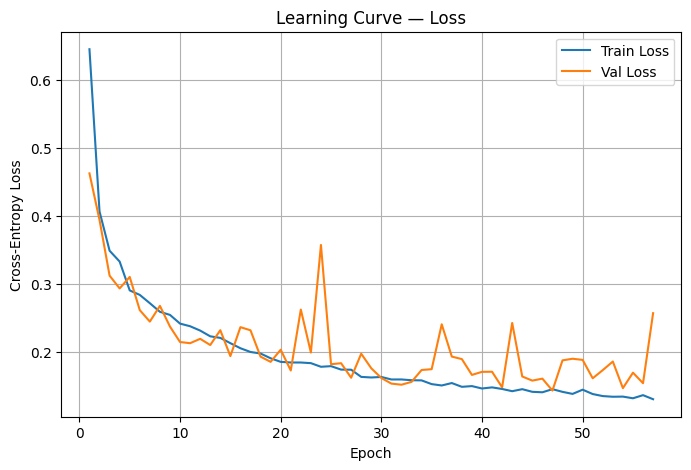

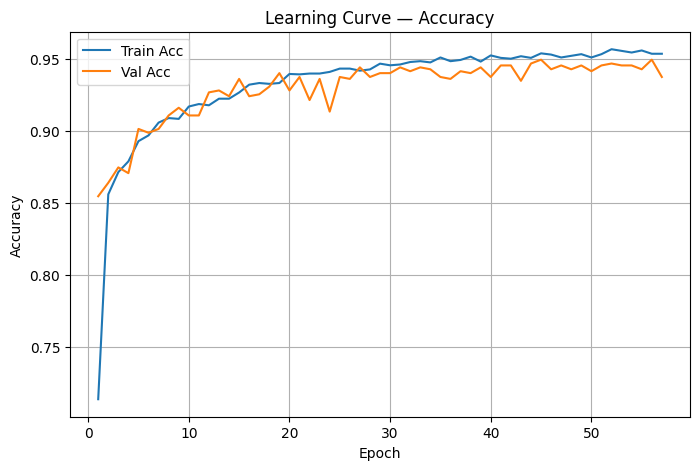

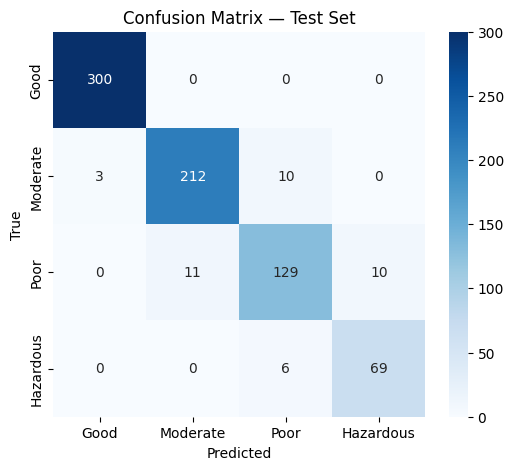

In [36]:
"""
Step 9 — Diagnostics: learning curves and confusion matrix visualization.

Assumes:
- `history` from training loop (list of dicts with train/val metrics).
- `cm` confusion matrix from Step 8.
- `CLASS_ORDER` for labeling classes.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---- 1) Convert history into DataFrame for easy plotting ----
history_df = pd.DataFrame(history)

# ---- 2) Plot training vs validation loss ----
plt.figure(figsize=(8,5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Learning Curve — Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- 3) Plot training vs validation accuracy ----
plt.figure(figsize=(8,5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Acc")
plt.plot(history_df["epoch"], history_df["val_acc"],   label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve — Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---- 4) Confusion matrix heatmap (from Step 8) ----
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.show()
